<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization
## **Name:** Tim Hollis
## **Assignment:** Weeks 5 & 6 Assignment
## **Date:** July 7, 2026

---

**Reference**

Motherboard VICE News. (2023). *Motherboard VICE News Kia Hyundai theft data* [Data set]. Google Sheets. https://docs.google.com/spreadsheets/d/1-6614t_Ata5k7oESrm-HAdF1uOe8aPGRaQECl44GYeE/edit#gid=0

USAFacts. (2023). *Car thefts are rising. Is a TikTok challenge to blame?* [Data set]. https://usafacts.org/data-projects/car-thefts

---

This notebook is a written data briefing prepared for the Milwaukee Common Council and city public safety officials on the surge in Kia and Hyundai vehicle thefts. It builds a case through six R visuals drawn from four datasets and closes with a specific funding request: free steering-wheel lock distribution and city-sponsored software-update clinics. A full discussion of audience, purpose, medium, design, and ethical considerations follows the briefing.

</div>

### **Initial Setup**

In [1]:
# Load Libraries while suppressing conflict errors
suppressPackageStartupMessages({
    library(tidyverse)
    library(readxl)
    library(treemapify)
    library(scales)
})

# Colorblind-safe palette
color_kia_hyundai <- '#4169E1'
color_other <- '#E69F00'
color_accent <- '#4B0082'
color_positive <- '#228B22'
color_gray_light <- '#D3D3D3'
color_gray_dark <- '#4D4D4D'

# Increase plot size
options(repr.plot.width = 15, repr.plot.height = 10)

# Consistent theme
theme_set(
    theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(face = 'bold', size = 15),
            plot.subtitle = element_text(color = color_accent),
            legend.position = 'bottom'
        )
)

# Month ordering used when converting month abbreviations to a plottable factor
month_levels <- c('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')

cat('✅ Setup complete: libraries loaded, palette and theme locked in\n')

✅ Setup complete: libraries loaded, palette and theme locked in


### **Data Loading and Cleaning**

The four datasets load here, then get cleaned: theft counts stored as text convert to numbers, month and year columns combine into real dates, and the VICE spreadsheet reshapes from a wide three-columns-per-city layout into a tidy format with one row per city per month.

In [2]:
# Load all four datasets
thefts_city_monthly <- read.csv('Thefts.csv')
thefts_milwaukee <- read.csv('TheftsMilwaukee.csv')
thefts_map_raw <- read.csv('TheftsMap.csv')
vice_raw <- read_excel('VICE.xlsx', .name_repair = 'unique_quiet') # Avoiding a print of renamed headers

# Add date column to datasets
thefts_city_monthly <- thefts_city_monthly |>
    mutate(
        month = factor(month, levels = month_levels),
        theft_date = make_date(year, match(month, month_levels), 1)
    )

thefts_milwaukee <- thefts_milwaukee |>
    mutate(
        month = factor(month, levels = month_levels),
        theft_date = make_date(year, match(month, month_levels), 1)
    )

# Convert text to numeric for year, suppressing warning since missing data becomes NA on purpose
thefts_map <- thefts_map_raw |>
    mutate(across(starts_with('countCarThefts'), ~ suppressWarnings(parse_number(.x))))

# Pair city and metric for each column before reshaping
vice_column_map <- tibble(
    column_name = names(vice_raw)[-1],
    metric = unlist(vice_raw[1, -1], use.names = FALSE)
) |>
    mutate(city = if_else(str_detect(column_name, '^\\.\\.\\.\\d+$'), NA_character_, column_name)) |>
    fill(city)

# Reshape to one row per city per month with Kia/Hyundai and total theft counts side by side
vice_tidy <- vice_raw |>
    slice(-1) |>
    rename(theft_month = `...1`) |>
    mutate(theft_month = as.Date(theft_month)) |>
    pivot_longer(-theft_month, names_to = 'column_name', values_to = 'value') |>
    left_join(vice_column_map, by = 'column_name') |>
    filter(metric %in% c('Kia/Hyundais', 'All')) |>
    mutate(value = as.numeric(value)) |>
    pivot_wider(id_cols = c(theft_month, city), names_from = metric, values_from = value) |>
    rename(kia_hyundai_thefts = `Kia/Hyundais`, all_thefts = All) |>
    mutate(other_thefts = all_thefts - kia_hyundai_thefts)

cat('✅ Thefts.csv:', format(nrow(thefts_city_monthly), big.mark = ','), 'rows across', n_distinct(thefts_city_monthly$city),
    'cities\n')
cat('✅ TheftsMilwaukee.csv:', nrow(thefts_milwaukee), 'rows covering', min(thefts_milwaukee$year),
    'to', max(thefts_milwaukee$year), '\n')
cat('✅ TheftsMap.csv:', format(nrow(thefts_map), big.mark = ','), 'agencies with numeric yearly counts\n')
cat('✅ VICE.xlsx: reshaped to', format(nrow(vice_tidy), big.mark = ','),
    'tidy rows across', n_distinct(vice_tidy$city), 'cities\n')

✅ Thefts.csv: 552 rows across 13 cities
✅ TheftsMilwaukee.csv: 48 rows covering 2019 to 2022 
✅ TheftsMap.csv: 556 agencies with numeric yearly counts
✅ VICE.xlsx: reshaped to 3,150 tidy rows across 70 cities


### **Kia and Hyundai Share of Milwaukee Thefts in 2022**

The story opens with the single most important fact for the Common Council: by 2022, nearly three of every five cars stolen in Milwaukee were a Kia or Hyundai. A simple two-slice pie makes that share impossible to miss for a non-technical audience.

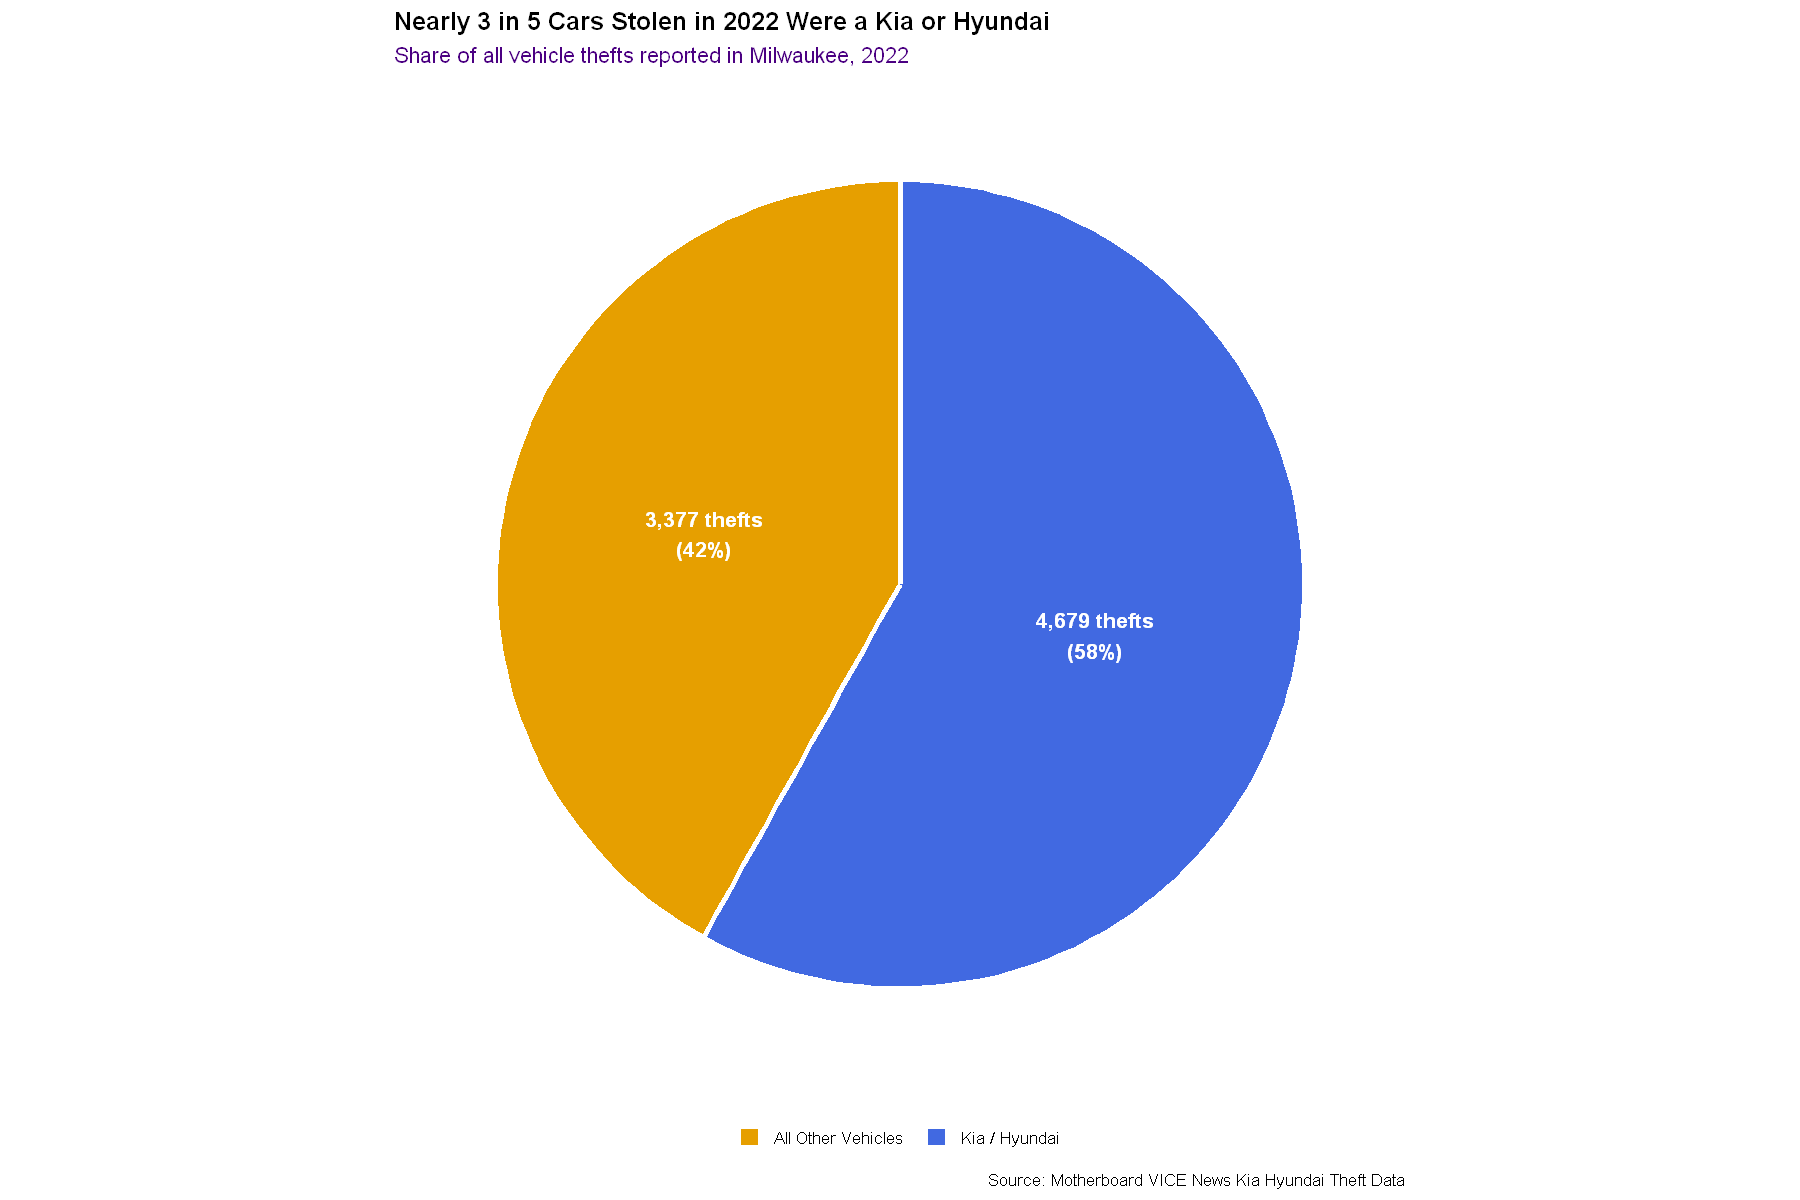

In [3]:
# Total the 2022 Milwaukee thefts into the two slices 
milwaukee_2022_share <- thefts_milwaukee |>
    filter(year == 2022) |>
    summarise(
        `Kia / Hyundai` = sum(countKiaHyundaiThefts),
        `All Other Vehicles` = sum(countOtherThefts)
    ) |>
    pivot_longer(everything(), names_to = 'vehicle_group', values_to = 'theft_count') |>
    mutate(
        share = theft_count / sum(theft_count),
        slice_label = paste0(comma(theft_count), ' thefts\n(', percent(share, accuracy = 1), ')')
    )

# Two-slice pie with counts and shares labeled directly 
ggplot(milwaukee_2022_share, aes(x = '', y = theft_count, fill = vehicle_group)) +
    geom_col(width = 1, color = 'white', linewidth = 1.5) +
    coord_polar(theta = 'y') +
    geom_text(aes(label = slice_label), position = position_stack(vjust = 0.5),
              color = 'white', fontface = 'bold', size = 4.5) +
    scale_fill_manual(values = c('Kia / Hyundai' = color_kia_hyundai,
                                 'All Other Vehicles' = color_other)) +
    labs(
        title = 'Nearly 3 in 5 Cars Stolen in 2022 Were a Kia or Hyundai',
        subtitle = 'Share of all vehicle thefts reported in Milwaukee, 2022',
        fill = NULL,
        caption = 'Source: Motherboard VICE News Kia Hyundai Theft Data'
    ) +
    theme(
        axis.title = element_blank(),
        axis.text = element_blank(),
        panel.grid = element_blank()
    )

### **Kia and Hyundai Share of Milwaukee Thefts in 2019**

The same measure three years earlier gives the council the before picture. In 2019, Kia and Hyundai thefts were a small fraction of the total. Pairing this donut with the pie above shows the shift from roughly one in twenty to nearly three in five.

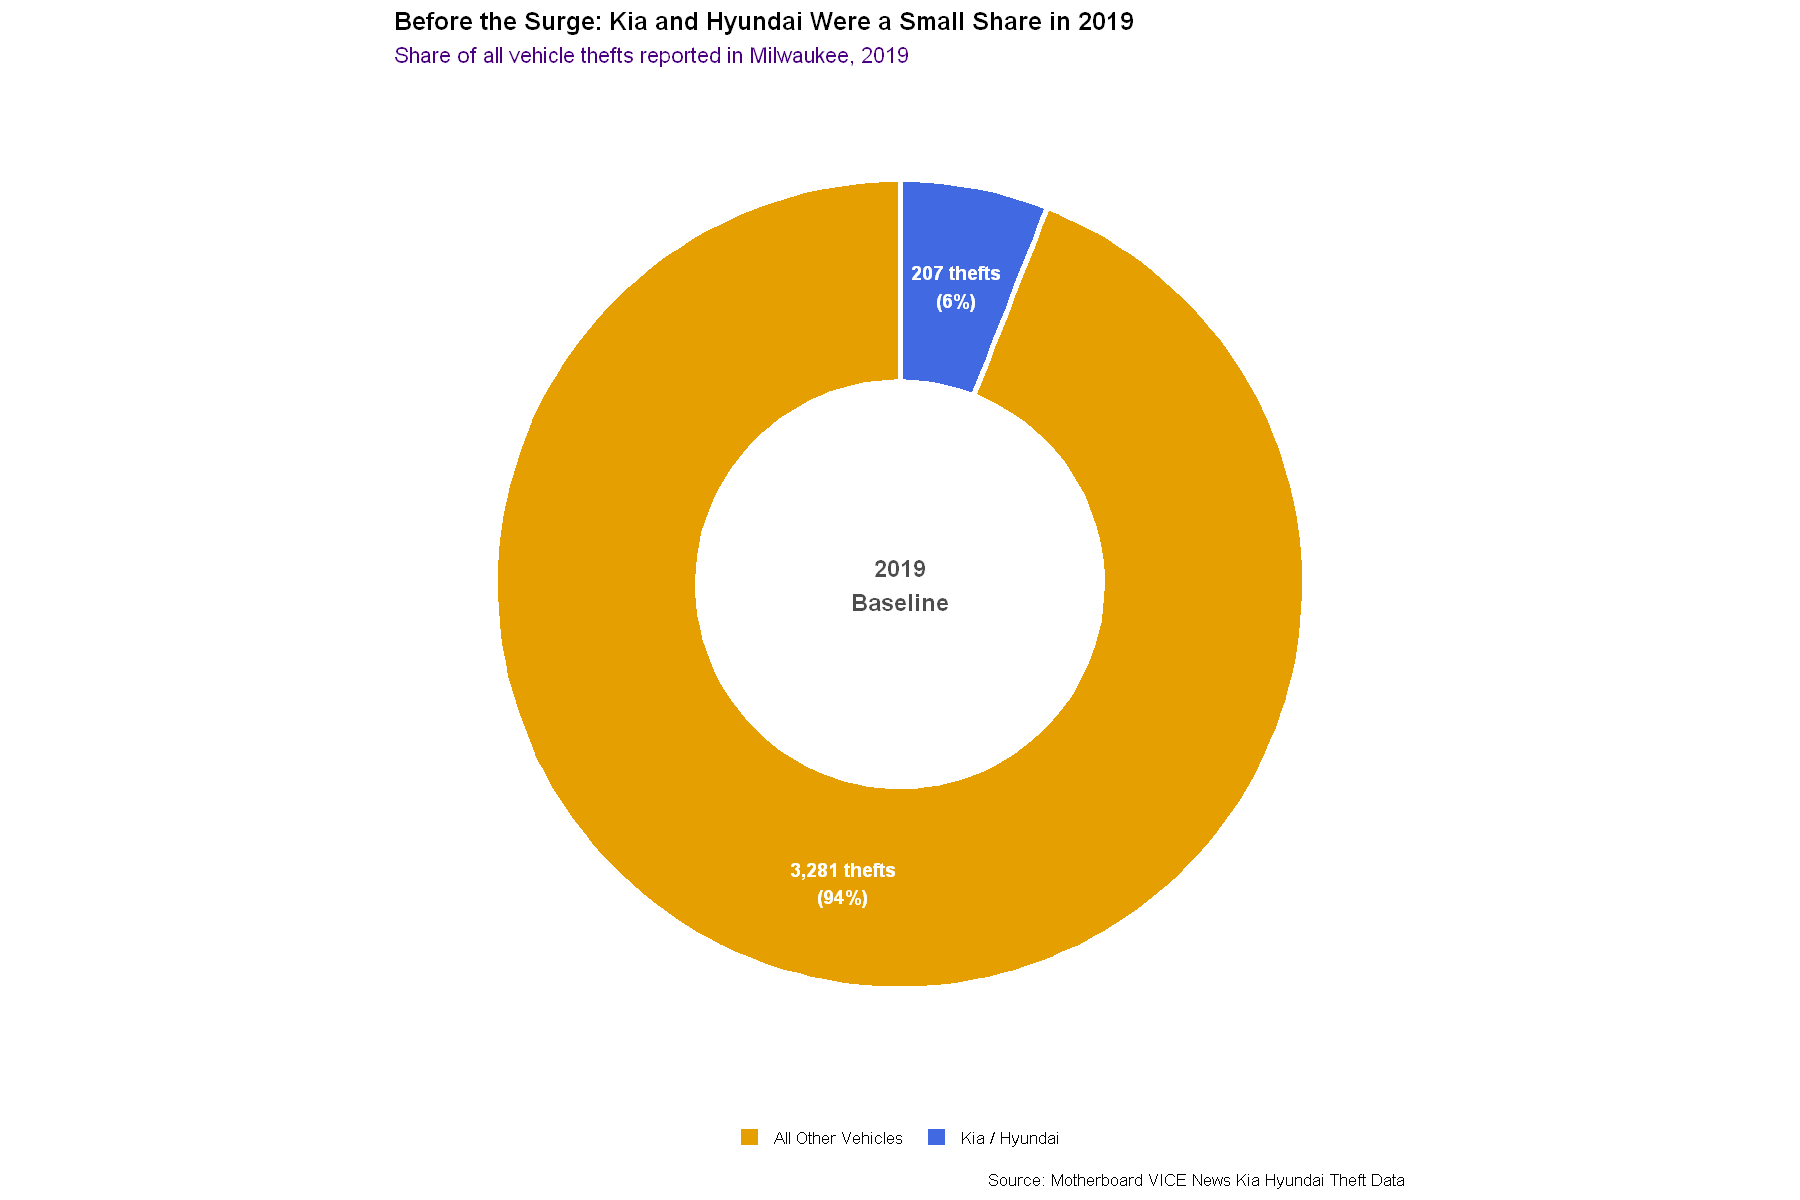

In [4]:
# Build the 2019 baseline slices using the same two groups as the 2022 pie
milwaukee_2019_share <- thefts_milwaukee |>
    filter(year == 2019) |>
    summarise(
        `Kia / Hyundai` = sum(countKiaHyundaiThefts),
        `All Other Vehicles` = sum(countOtherThefts)
    ) |>
    pivot_longer(everything(), names_to = 'vehicle_group', values_to = 'theft_count') |>
    mutate(
        share = theft_count / sum(theft_count),
        slice_label = paste0(comma(theft_count), ' thefts\n(', percent(share, accuracy = 1), ')')
    )

# Same pie construction with x moved to 2 and an xlim to hollow out the center
ggplot(milwaukee_2019_share, aes(x = 2, y = theft_count, fill = vehicle_group)) +
    geom_col(width = 1, color = 'white', linewidth = 1.5) +
    coord_polar(theta = 'y') +
    xlim(0.5, 2.5) +
    geom_text(aes(label = slice_label), position = position_stack(vjust = 0.5),
              color = 'white', fontface = 'bold', size = 4) +
    annotate('text', x = 0.5, y = 0, label = '2019\nBaseline',
             fontface = 'bold', size = 5, color = color_gray_dark) +
    scale_fill_manual(values = c('Kia / Hyundai' = color_kia_hyundai,
                                 'All Other Vehicles' = color_other)) +
    labs(
        title = 'Before the Surge: Kia and Hyundai Were a Small Share in 2019',
        subtitle = 'Share of all vehicle thefts reported in Milwaukee, 2019',
        fill = NULL,
        caption = 'Source: Motherboard VICE News Kia Hyundai Theft Data'
    ) +
    theme(
        axis.title = element_blank(),
        axis.text = element_blank(),
        panel.grid = element_blank()
    )

<hr style="page-break-before: always;">

### **2022 Thefts by City, Kia and Hyundai vs. All Other Vehicles**

Widening the lens to the 13 cities tracked in the monthly data shows the council two things at once: total theft volume by city, and how much of each city's problem is the Kia and Hyundai wave. Sorting by Kia and Hyundai count puts Milwaukee at the top of the comparison.

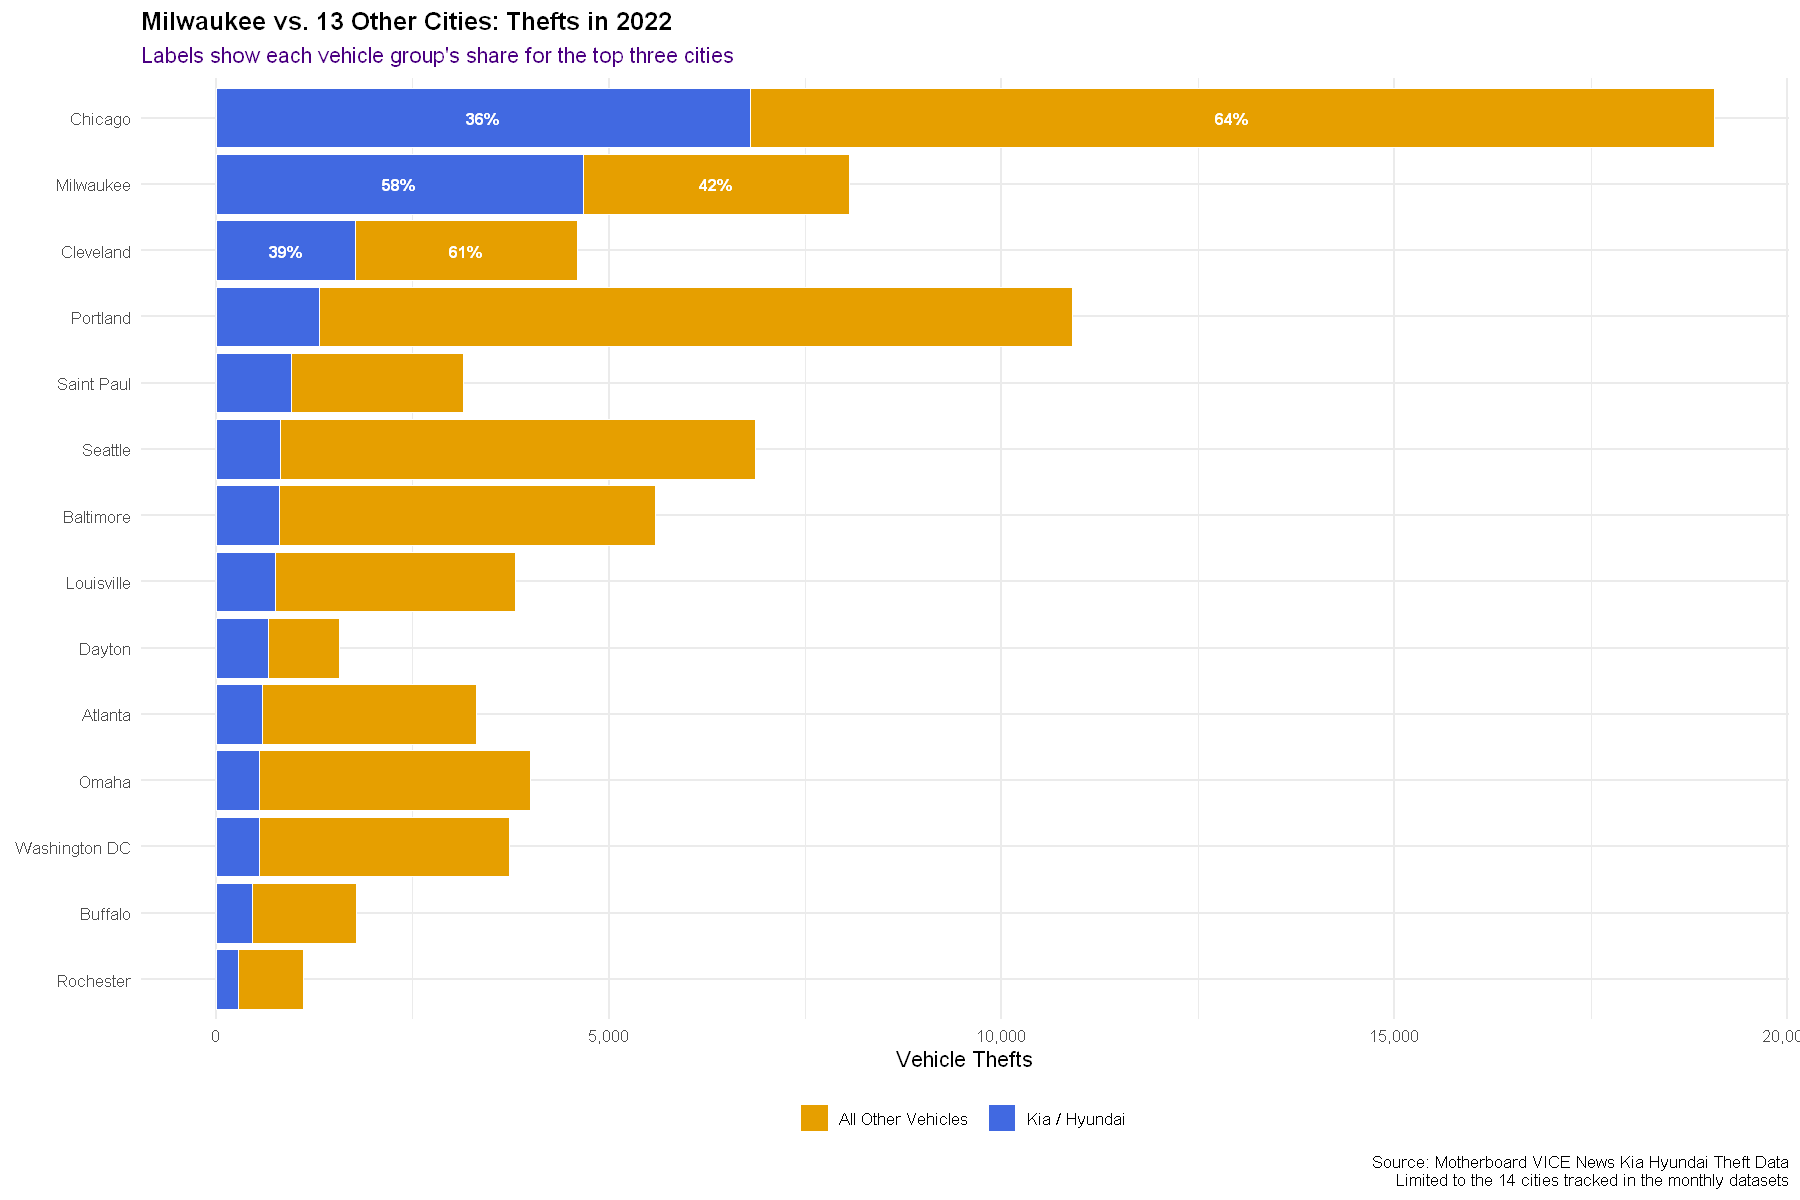

In [5]:
# Combine the 13-city monthly data with Milwaukee so the comparison includes all 14
city_2022_totals <- thefts_city_monthly |>
    bind_rows(thefts_milwaukee) |>
    filter(year == 2022) |>
    group_by(city) |>
    summarise(
        `Kia / Hyundai` = sum(countKiaHyundaiThefts),
        `All Other Vehicles` = sum(countOtherThefts),
        .groups = 'drop'
    )

# Order cities by Kia/Hyundai count 
city_order <- city_2022_totals |>
    arrange(`Kia / Hyundai`) |>
    pull(city)

city_2022_stacked <- city_2022_totals |>
    pivot_longer(-city, names_to = 'vehicle_group', values_to = 'theft_count') |>
    mutate(
        vehicle_group = factor(vehicle_group, levels = c('All Other Vehicles', 'Kia / Hyundai')),
        city = factor(city, levels = city_order)
    )

# Percent labels at each segment midpoint for the three leading cities
top_city_labels <- city_2022_totals |>
    slice_max(`Kia / Hyundai`, n = 3) |>
    mutate(
        total = `Kia / Hyundai` + `All Other Vehicles`,
        kia_mid = `Kia / Hyundai` / 2,
        other_mid = `Kia / Hyundai` + `All Other Vehicles` / 2,
        kia_pct = percent(`Kia / Hyundai` / total, accuracy = 1),
        other_pct = percent(`All Other Vehicles` / total, accuracy = 1)
    ) |>
    select(city, kia_mid, other_mid, kia_pct, other_pct) |>
    pivot_longer(-city, names_to = c('segment', '.value'), names_sep = '_') |>
    mutate(city = factor(city, levels = city_order))

# Horizontal stacked bars so city names read naturally
ggplot(city_2022_stacked, aes(x = theft_count, y = city, fill = vehicle_group)) +
    geom_col(color = 'white', linewidth = 0.3) +
    geom_text(data = top_city_labels,
              aes(x = mid, y = city, label = pct),
              inherit.aes = FALSE, color = 'white', fontface = 'bold', size = 3.6) +
    scale_fill_manual(values = c('Kia / Hyundai' = color_kia_hyundai,
                                 'All Other Vehicles' = color_other)) +
    scale_x_continuous(labels = comma) +
    labs(
        title = 'Milwaukee vs. 13 Other Cities: Thefts in 2022',
        subtitle = 'Labels show each vehicle group\'s share for the top three cities',
        x = 'Vehicle Thefts',
        y = NULL,
        fill = NULL,
        caption = paste(
            'Source: Motherboard VICE News Kia Hyundai Theft Data',
            'Limited to the 14 cities tracked in the monthly datasets',
            sep = '\n')
        )


### **2022 Kia and Hyundai Thefts Across All Tracked Cities**

The VICE dataset tracks roughly 70 cities, far more than the monthly files. A treemap sizes each city by its 2022 Kia and Hyundai theft count, letting the council see the entire national landscape in one view and Milwaukee's outsized footprint within it. Cities with no reported Kia and Hyundai counts in 2022 are excluded and noted below the chart.

🔎 Cities with 2022 Kia/Hyundai data: 68 
🔎 Milwaukee present: TRUE 



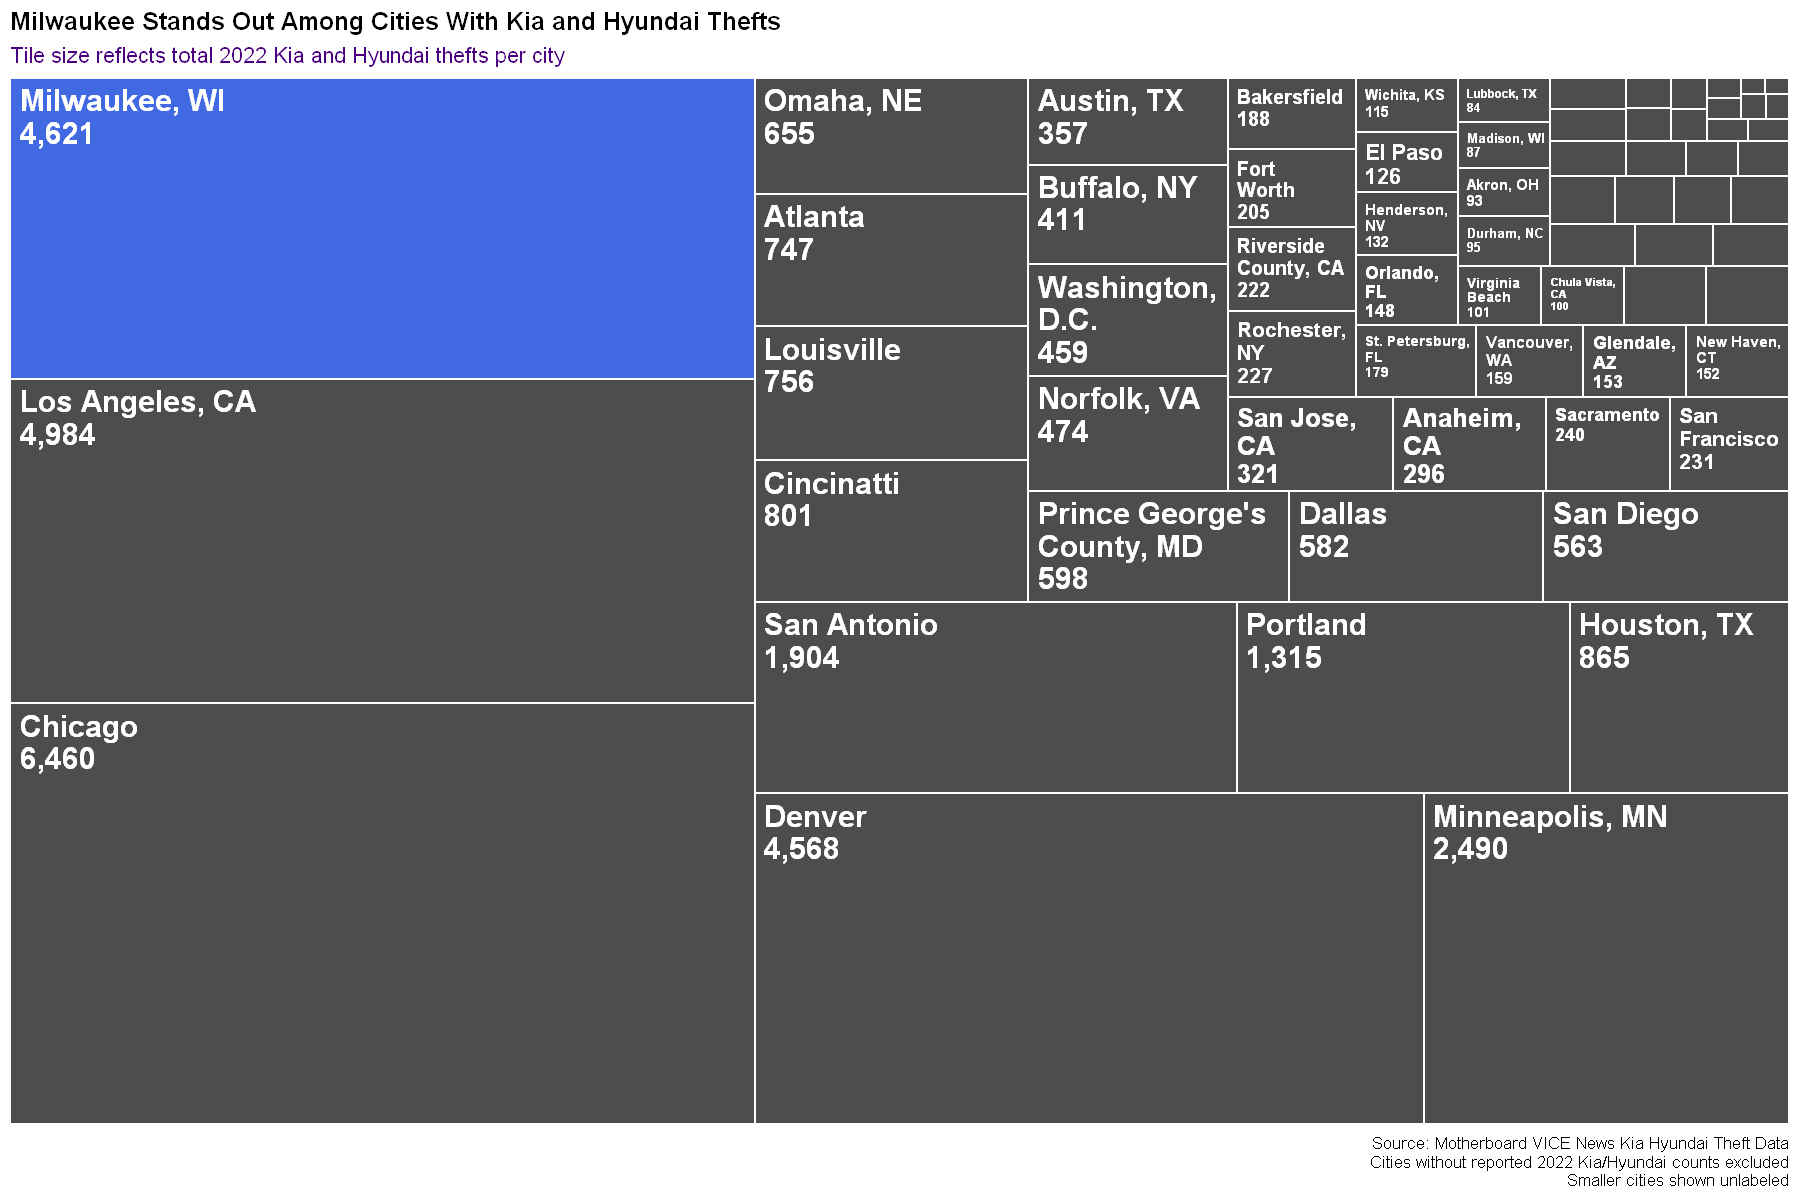

In [6]:
# Total 2022 Kia/Hyundai thefts per city from the reshaped VICE data
vice_2022_treemap <- vice_tidy |>
    filter(year(theft_month) == 2022, !is.na(kia_hyundai_thefts)) |>
    group_by(city) |>
    summarise(kia_hyundai_thefts = sum(kia_hyundai_thefts), .groups = 'drop') |>
    filter(kia_hyundai_thefts > 0) |>
    mutate(
        is_milwaukee = str_detect(city, 'Milwaukee'),
        tile_label = paste0(city, '\n', comma(kia_hyundai_thefts))
    )

cat('🔎 Cities with 2022 Kia/Hyundai data:', nrow(vice_2022_treemap), '\n')
cat('🔎 Milwaukee present:', any(vice_2022_treemap$is_milwaukee), '\n\n')

# Treemap sized by theft count with Milwaukee called out in the story's blue
ggplot(vice_2022_treemap, aes(area = kia_hyundai_thefts, fill = is_milwaukee, label = tile_label)) +
    geom_treemap(color = 'white', size = 2) +
    geom_treemap_text(color = 'white', fontface = 'bold', reflow = TRUE,
                      padding.x = grid::unit(2, 'mm'), padding.y = grid::unit(2, 'mm'),
                      min.size = 6) +
    scale_fill_manual(values = c(`TRUE` = color_kia_hyundai, `FALSE` = color_gray_dark),
                      guide = 'none') +
    labs(
        title = 'Milwaukee Stands Out Among Cities With Kia and Hyundai Thefts',
        subtitle = 'Tile size reflects total 2022 Kia and Hyundai thefts per city',
        caption = paste(
            'Source: Motherboard VICE News Kia Hyundai Theft Data',
            'Cities without reported 2022 Kia/Hyundai counts excluded',
            'Smaller cities shown unlabeled',
            sep = '\n')
    )

### **Milwaukee Kia and Hyundai Thefts by Month, 2019 to 2022**

The timeline answers the council's natural question: when did this start? Monthly Kia and Hyundai thefts in Milwaukee sat near twenty per month for nearly two years, then doubled every month starting in October 2020, from 39 in September to 406 by December. Milwaukee was not swept up in a national trend; the wave started here, months before it spread to other cities. The filled area emphasizes the cumulative volume of stolen vehicles, not just the trend.

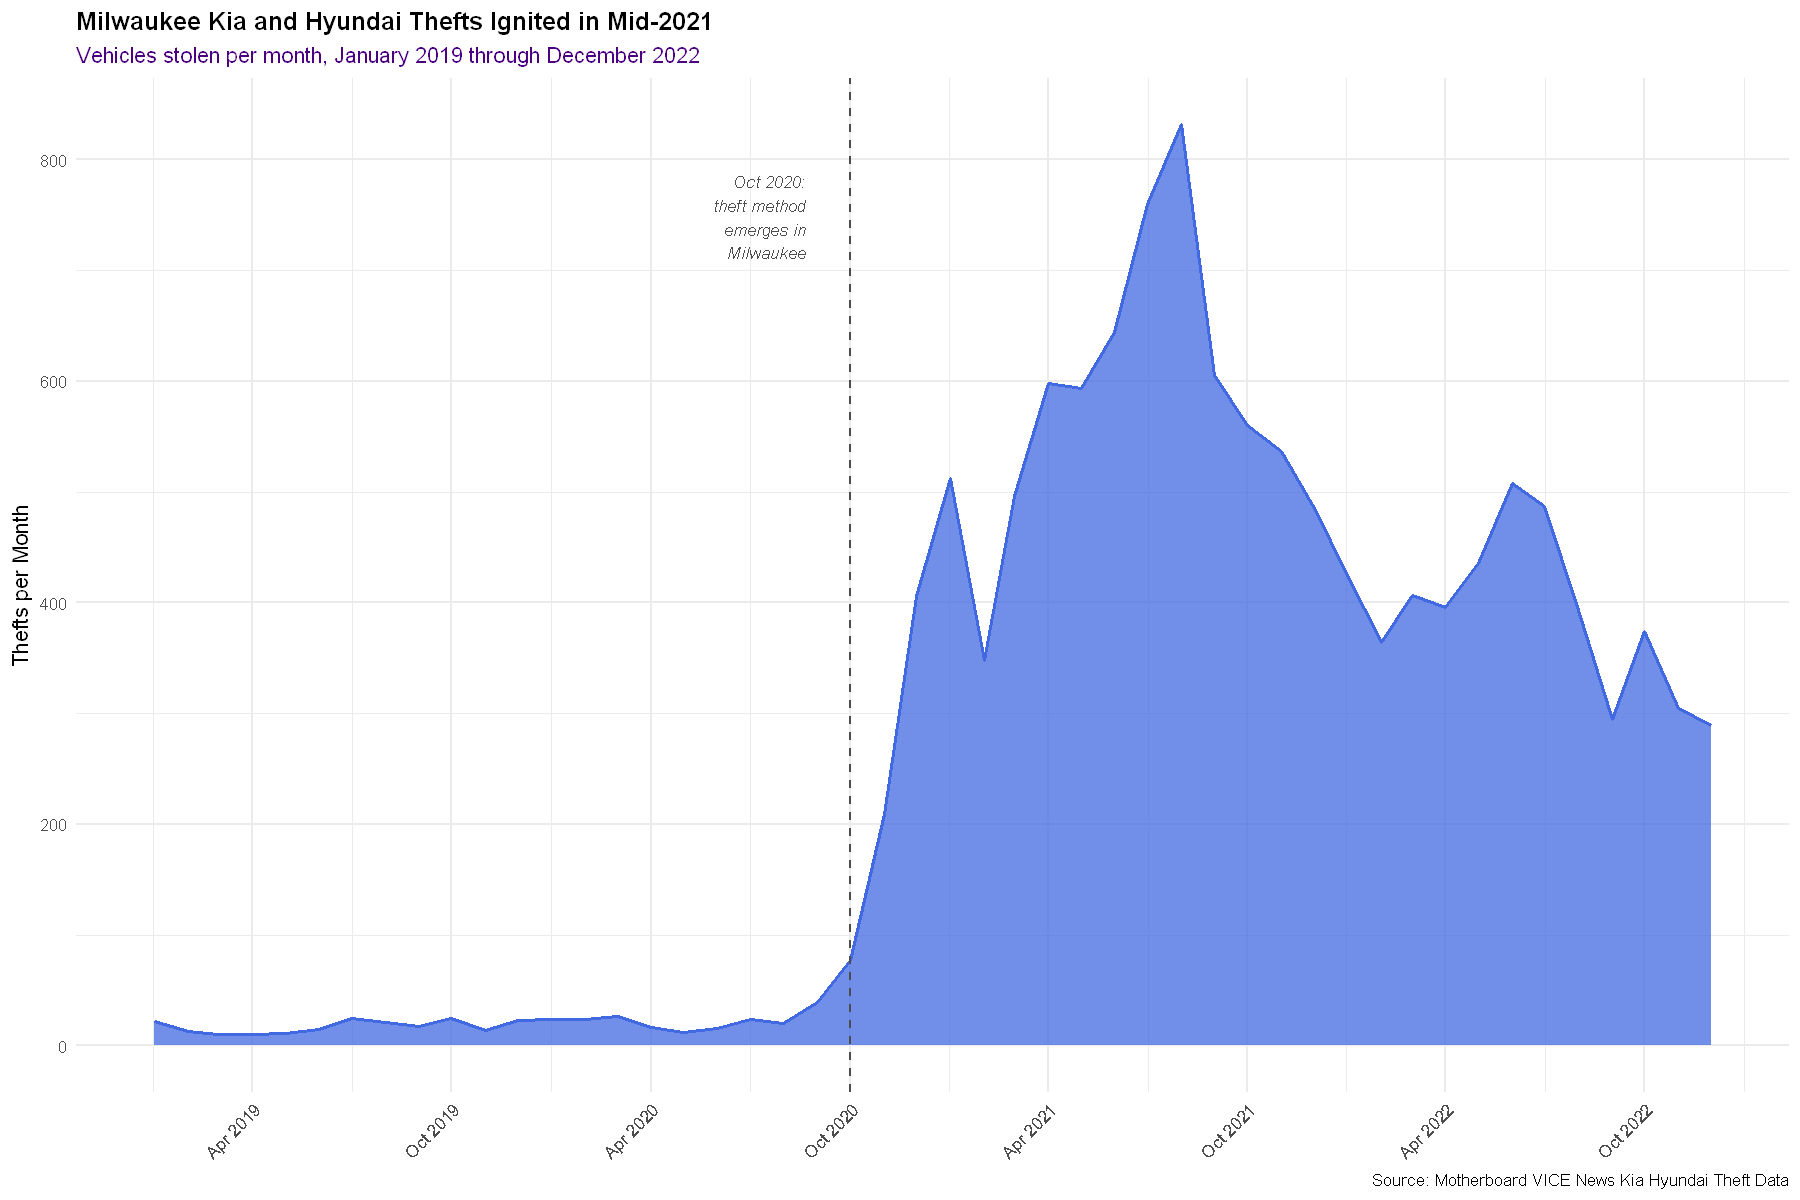

In [7]:
# Monthly Milwaukee Kia/Hyundai thefts across the full four-year window
milwaukee_monthly <- thefts_milwaukee |>
    arrange(theft_date)

# Anchor the surge's takeoff point for context
surge_start <- as.Date('2020-10-01')

# Filled area to convey cumulative weight, with the surge onset flagged directly
ggplot(milwaukee_monthly, aes(x = theft_date, y = countKiaHyundaiThefts)) +
    geom_area(fill = color_kia_hyundai, alpha = 0.75) +
    geom_line(color = color_kia_hyundai, linewidth = 1) +
    geom_vline(xintercept = surge_start, linetype = 'dashed', color = color_gray_dark) +
    annotate('text', x = surge_start - 40, y = max(milwaukee_monthly$countKiaHyundaiThefts) * 0.9,
             label = 'Oct 2020:\ntheft method\nemerges in\nMilwaukee', hjust = 1, size = 3.5,
             color = color_gray_dark, fontface = 'italic') +
    scale_x_date(date_breaks = '6 months', date_labels = '%b %Y') +
    scale_y_continuous(labels = comma) +
    labs(
        title = 'Milwaukee Kia and Hyundai Thefts Ignited in Mid-2021',
        subtitle = 'Vehicles stolen per month, January 2019 through December 2022',
        x = NULL,
        y = 'Thefts per Month',
        caption = 'Source: Motherboard VICE News Kia Hyundai Theft Data'
    ) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

### **The Theft Surge Is Mostly a Kia and Hyundai Surge**

The final visual stacks Kia and Hyundai thefts against all other vehicle thefts across the 14 tracked cities, month by month. Thefts of other vehicles rose modestly over the four years, but the Kia and Hyundai band grew from a sliver to nearly half the total by late 2022. Most of the surge traces to two brands with a known, fixable vulnerability, which means targeted measures like steering wheel locks and software updates can reverse the bulk of it.

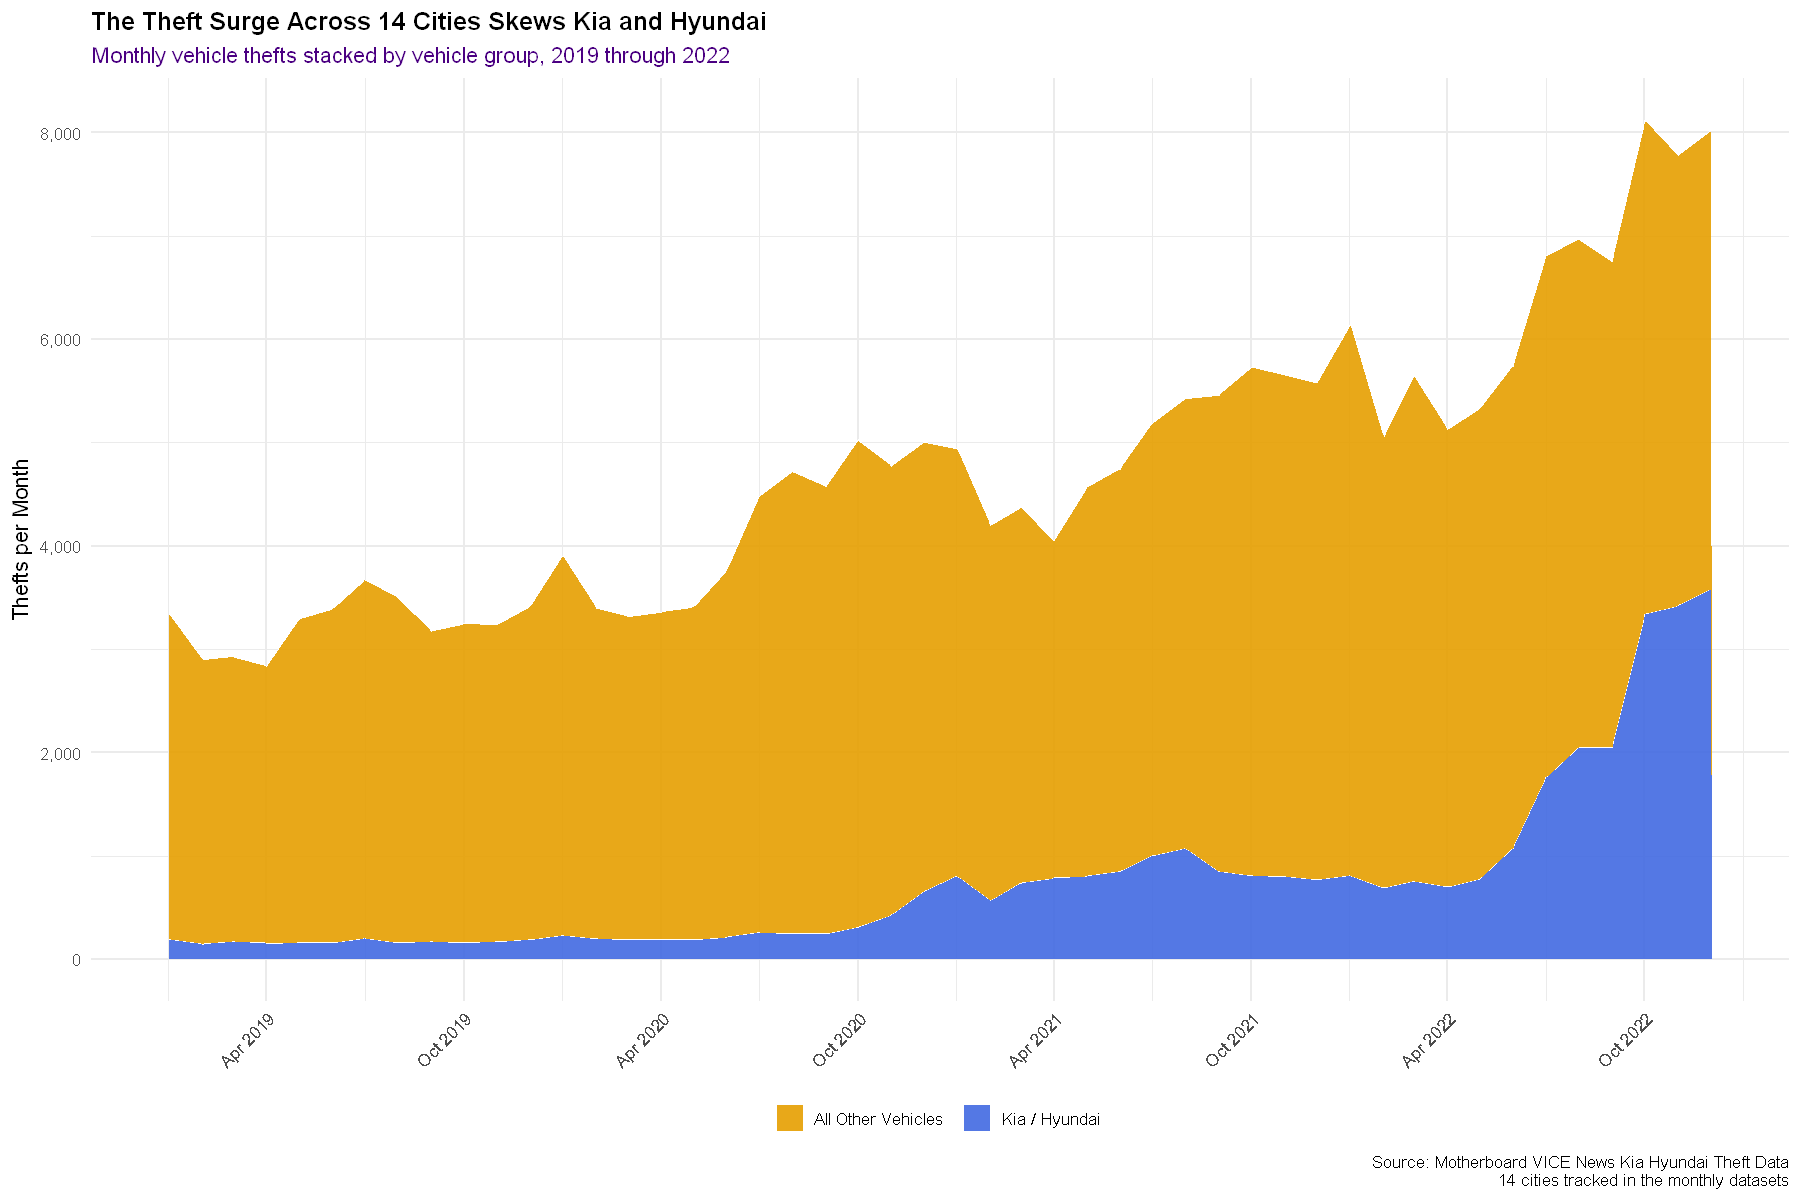

In [8]:
# Combine all 14 monthly-tracked cities and stack the two vehicle groups over time
national_monthly_stacked <- thefts_city_monthly |>
    bind_rows(thefts_milwaukee) |>
    group_by(theft_date) |>
    summarise(
        `Kia / Hyundai` = sum(countKiaHyundaiThefts),
        `All Other Vehicles` = sum(countOtherThefts),
        .groups = 'drop'
    ) |>
    pivot_longer(-theft_date, names_to = 'vehicle_group', values_to = 'theft_count') |>
    mutate(vehicle_group = factor(vehicle_group, levels = c('Kia / Hyundai', 'All Other Vehicles')))

# Stacked area with Kia/Hyundai on the bottom so its growth reads against a flat baseline
ggplot(national_monthly_stacked, aes(x = theft_date, y = theft_count, fill = vehicle_group)) +
    geom_area(color = 'white', linewidth = 0.4, alpha = 0.9,
              position = position_stack(reverse = TRUE)) +
    guides(fill = guide_legend(reverse = TRUE)) +
    scale_fill_manual(values = c('Kia / Hyundai' = color_kia_hyundai,
                                 'All Other Vehicles' = color_other)) +
    scale_x_date(date_breaks = '6 months', date_labels = '%b %Y') +
    scale_y_continuous(labels = comma) +
    labs(
        title = 'The Theft Surge Across 14 Cities Skews Kia and Hyundai',
        subtitle = 'Monthly vehicle thefts stacked by vehicle group, 2019 through 2022',
        x = NULL,
        y = 'Thefts per Month',
        fill = NULL,
        caption = paste(
            'Source: Motherboard VICE News Kia Hyundai Theft Data',
            '14 cities tracked in the monthly datasets',
            sep = '\n')
        ) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

### **Call to Action**

The data supports one conclusion: Milwaukee's theft surge is concentrated in two brands with a known, fixable vulnerability, and Milwaukee has lived with it longer than any other city. The ask for the Common Council is specific:

**Approve funding for a two-part Vehicle Theft Prevention Initiative:**

1. **Free steering wheel lock distribution** targeted to registered owners of 2011-2021 Kia and Hyundai models, prioritized by the neighborhoods with the highest theft counts. Locks are an immediate, proven physical deterrent available for under $50 per vehicle.
2. **City-sponsored software update clinics** in partnership with local Kia and Hyundai dealers, bringing the manufacturers' free anti-theft software patch to owners who cannot easily reach a dealership. The patch closes the ignition vulnerability these thefts exploit.

Every month of delay costs Milwaukee hundreds of stolen vehicles, insurance claims, police hours, and residents stranded without transportation. The fix is known, inexpensive, and waiting on approval.

<hr style="page-break-before: always;">

### **Summary**

This notebook told a data story for the Milwaukee Common Council using four datasets on the Kia and Hyundai theft wave. Six visuals traced the arc: a pie and donut pair showed Milwaukee's Kia and Hyundai theft share exploding from 6 percent in 2019 to 58 percent in 2022, stacked bars placed Milwaukee's problem among 13 peer cities, a treemap showed its outsized footprint across roughly 70 cities nationally, an area chart pinned the surge's ignition to October 2020, and a stacked area chart showed the multi-city surge concentrating in the two affected brands. The story closed with a funded, two-part call to action: steering wheel lock distribution and software update clinics.

### **Audience, Purpose, Medium, Design, and Ethical Considerations**

My audience is the Milwaukee Common Council and city public safety officials. They are policy-literate but unfamiliar with the underlying data and not technical, so every visual makes one point, avoids jargon, labels values directly, and keeps the same two-color vocabulary throughout. My purpose is a specific call to action: approve funding for free steering wheel lock distribution in the hardest-hit neighborhoods and city-sponsored software update clinics with local Kia and Hyundai dealers. I want the council to walk away knowing three things: the surge is concentrated in two brands, it started in Milwaukee before it spread nationally, and the vulnerability driving it is fixable. My medium is this written data briefing, a narrative document that interleaves prose with the six R visuals and closes with the funding request. Council members receive written briefing packets before votes, so a self-contained PDF that builds the argument section by section and can be read in ten minutes fits how this audience actually consumes information, and it lets the call to action live inside the same document as the evidence supporting it.

Gestalt principles shaped the design. Figure-ground drives the pie and treemap, where royal blue against amber or neutral gray makes the Kia and Hyundai share the figure. Similarity connects the pie and donut pair, since identical colors and labels signal the same measure at two points in time. The treemap uses a single highlight color against gray tiles to create one focal point instead of confetti. On the stacked area chart, the Kia and Hyundai band sits on the axis because only the bottom band reads against a stable baseline. Color stayed limited to a colorblind-safe palette, text was kept to direct labels with takeaway titles and scope subtitles, and consistent alignment, sizing, and spacing came from a single global theme.

Several transformations required ethical care. Theft counts stored as text were converted to numbers, and one agency reported a dash instead of a count, which I treated as missing rather than zero. The VICE spreadsheet was reshaped from a wide layout into tidy rows, and I recomputed percentages rather than trusting pre-calculated fields. Cities without reported 2022 Kia and Hyundai counts were excluded from the treemap, and that filter is labeled in the caption rather than hidden. Counts for the same city differ slightly across datasets due to reporting windows, so each visual cites its specific source. I initially placed the surge annotation from news reporting, then verified it against the data and moved it to October 2020, where the numbers actually turn. Chart titles were revised to claim no more than the data shows. The data was compiled by Motherboard VICE News journalists through public records requests and by USAFacts from law enforcement reporting, both publicly documented and ethically acquired sources. The main remaining risks are that fourteen tracked cities are not a national sample and that neighborhood-level targeting could stigmatize areas with high theft counts. I would mitigate these by stating coverage limits in each visual's caption, as done throughout this briefing, and by framing targeted distribution as resource prioritization for affected residents rather than as blame.

# Reflection for Week 5

## General Reflection
This week was all about turning the Kia and Hyundai theft datasets into a real story instead of just a set of charts. Once I dug into the numbers, the pattern in Milwaukee jumped out immediately. The line that stuck with me from the briefing was “By 2022, nearly three of every five cars stolen in Milwaukee were a Kia or Hyundai.” That became the anchor for the whole narrative. Building the visuals in R felt smoother this time because the story had a clear direction. I liked shaping the briefing for the Milwaukee Common Council since it pushed me to think about how nontechnical decision makers actually read data. The call to action made the assignment feel more like something that could exist in the real world. The two-part recommendation of steering wheel locks and software update clinics came straight from what the data showed. I also spent more time thinking about ethical choices than usual, especially around reshaping the VICE dataset and labeling filters. Overall, this week helped me practice the difference between showing data and telling a story with it.

## Straightforward Aspects
- The pie and donut charts were easy to build once the Milwaukee data was cleaned.
- The stacked bar chart made the city comparisons clear without much tweaking.
- The treemap worked well for highlighting Milwaukee’s footprint among the seventy cities.

## Challenging Aspects
- Cleaning the VICE dataset took patience because of the wide layout and mixed data types.
- Making sure every transformation was ethically documented required extra attention.
- Balancing simplicity for the audience with enough detail to support the call to action took some trial and error.
